In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

In [2]:
with open(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\model.pkl', 'rb') as f: 
    model = pickle.load(f)

with open(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\preprocessor.pkl', 'rb') as f: 
    preprocessor = pickle.load(f)

In [3]:
X_test = pd.DataFrame([{
    'property_type': 'house',
    'sector': 'sector 43',
    'bedRoom': 4,
    'bathroom': 4,
    'balcony': '2',
    'agePossession': 'under construction',
    'built_up_area': 2430.06,
    'servant room': 1,
    'store room': 1,
    'furnishing_type': 'furnished',
    'luxury_category': 'luxury',
    'floor_category': 'medium-rise'
}])

In [4]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model)
])

In [5]:
y_pred = pipeline.predict(X_test)
print(y_pred)

[2.01982602]


In [6]:
print(np.expm1(y_pred))

[6.53701355]


In [7]:
test_df = pd.read_csv(r"C:\Users\apaks\Desktop\Real Estate Project\artifacts\test.csv")

In [8]:
test_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 109,6.80,4,5,3,relatively new,5400.00,1,0,unfurnished,budget,low-rise
1,flat,sector 56,1.38,3,3,3,relatively old,1910.00,0,0,semifurnished,luxury,medium-rise
2,flat,sector 86,0.90,3,3,2,new,1690.00,0,0,unfurnished,budget,medium-rise
3,house,sector 47,0.49,2,2,1,new,1150.00,0,0,unfurnished,budget,low-rise
4,flat,sector 49,3.00,4,4,3,relatively old,2200.00,1,0,semifurnished,luxury,medium-rise
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,flat,sector 22,4.30,3,4,3+,relatively new,2600.00,1,0,furnished,luxury,medium-rise
696,flat,sector 91,0.95,2,2,2,relatively new,1191.00,0,0,unfurnished,semi-luxury,medium-rise
697,house,sector 43,5.25,4,4,2,old,1934.98,1,0,semifurnished,semi-luxury,low-rise
698,flat,sector 47,0.40,2,2,2,new,900.00,0,0,unfurnished,semi-luxury,low-rise


In [9]:
X = test_df.drop(columns = ['price'])
y = test_df['price']

In [10]:
X

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 109,4,5,3,relatively new,5400.00,1,0,unfurnished,budget,low-rise
1,flat,sector 56,3,3,3,relatively old,1910.00,0,0,semifurnished,luxury,medium-rise
2,flat,sector 86,3,3,2,new,1690.00,0,0,unfurnished,budget,medium-rise
3,house,sector 47,2,2,1,new,1150.00,0,0,unfurnished,budget,low-rise
4,flat,sector 49,4,4,3,relatively old,2200.00,1,0,semifurnished,luxury,medium-rise
...,...,...,...,...,...,...,...,...,...,...,...,...
695,flat,sector 22,3,4,3+,relatively new,2600.00,1,0,furnished,luxury,medium-rise
696,flat,sector 91,2,2,2,relatively new,1191.00,0,0,unfurnished,semi-luxury,medium-rise
697,house,sector 43,4,4,2,old,1934.98,1,0,semifurnished,semi-luxury,low-rise
698,flat,sector 47,2,2,2,new,900.00,0,0,unfurnished,semi-luxury,low-rise


In [11]:
y 

0      6.80
1      1.38
2      0.90
3      0.49
4      3.00
       ... 
695    4.30
696    0.95
697    5.25
698    0.40
699    2.20
Name: price, Length: 700, dtype: float64

In [12]:
y.shape

(700,)

In [13]:
y_pred = np.expm1(pipeline.predict(X))

In [14]:
y_pred.shape

(700,)

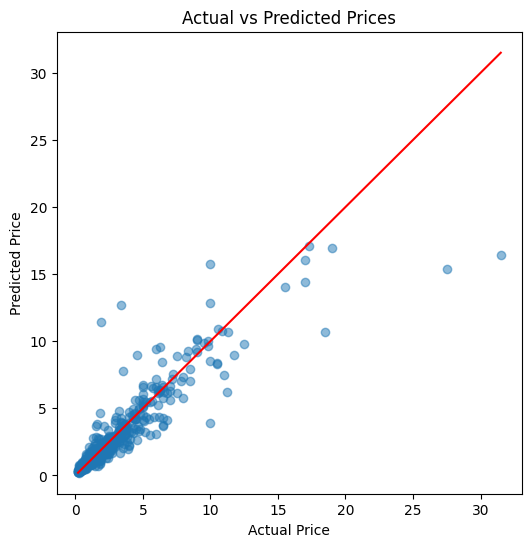

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score, KFold

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print('r2: ', r2)
print('mae: ', mae)
print('rmse: ', rmse)
kfold = KFold(n_splits = 10, shuffle = True, random_state = 42)
scores = cross_val_score(pipeline, X, y, cv = kfold, scoring = 'r2', n_jobs = -1, verbose = 0)

print('mean r2 score: ', scores.mean())
print('std deviation: ', scores.std())


r2:  0.824785668559967
mae:  0.4798133209316422
rmse:  1.2214247276126355
mean r2 score:  0.7546034677750688
std deviation:  0.16020487334128983


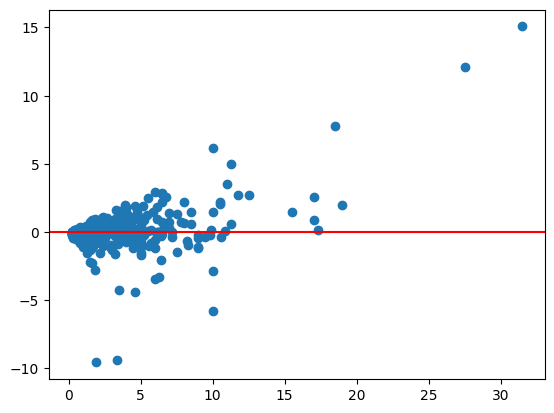

In [17]:
residuals = y - y_pred

plt.scatter(y, residuals)
plt.axhline(0, color='red')

In [18]:
y.mean()

np.float64(2.519842857142857)

# Prediction pipeline testing

In [19]:
X_test = pd.DataFrame([{
    'property_type': 'house',
    'sector': 'sector 43',
    'bedRoom': 4,
    'bathroom': 4,
    'balcony': '2',
    'agePossession': 'under construction',
    'built_up_area': 2430.06,
    'servant room': 1,
    'store room': 1,
    'furnishing_type': 'furnished',
    'luxury_category': 'luxury',
    'floor_category': 'medium-rise'
}])

In [37]:
from src.pipelines.predict_pipeline import PredictPipeline, CustomData

input_data = CustomData(
    property_type= 'house',
    sector='sector 80',
    bedroom= 3,
    bathroom= 4,
    balcony= '2',
    agePossession= 'under construction',
    built_up_area= 2000,
    servant_room= 1,
    store_room= 1,
    furnishing_type= 'furnished',
    luxury_category= 'luxury',
    floor_category= 'medium-rise'
)

pipeline = PredictPipeline()
df = input_data.get_data_as_df()
print(np.expm1(pipeline.predict(df)))

[3.42898735]
